# Hospital Readmission Prediction — LightGBM + XAI

**Dataset:** UCI Diabetes 130-US Hospitals (Brandao, Kaggle)  
**Task:** 3-class readmission prediction — No Readmit (0) / >30 Days (1) / <30 Days (2)  
**Model:** LightGBM with hyperparameter tuning  
**Explainability Techniques:** SHAP · PDP · LIME · Permutation Importance  

---
**Pipeline:**  
Data Loading → Preprocessing → EDA → Feature Engineering/Selection → Model Training → Evaluation → Learning/Validation Curves → XAI Explainability (4 techniques)


# **1-Load Needed Libraries and Preproccessing**

---



---



In [1]:
import kagglehub
import os
import math
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

!pip install lime
import lime
import lime.lime_tabular

import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, classification_report
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

path = kagglehub.dataset_download('brandao/diabetes')
print('Path to dataset files:', path)

file_path = os.path.join(path, [f for f in os.listdir(path) if f.endswith('.csv')][0])
df = pd.read_csv(file_path)
print('Original dataset shape:', df.shape)
df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 24.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=58d98b4bedc5458f9499fb6fe06452e45eb585b8a23e65e2f16e55764cbfa1fb
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


100%|██████████| 4.41M/4.41M [00:01<00:00, 3.46MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/brandao/diabetes/versions/1
Original dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [2]:
df["weight"].value_counts()

,count
weight,
?,98569
[75-100),1336
[50-75),897
[100-125),625
[125-150),145
[25-50),97
[0-25),48
[150-175),35
[175-200),11


In [3]:
df["payer_code"].value_counts()

,count
payer_code,
?,40256
MC,32439
HM,6274
SP,5007
BC,4655
MD,3532
CP,2533
UN,2448
CM,1937


In [4]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [5]:
df = df[df['race'] != '?']
df = df[df['gender'] != 'Unknown/Invalid']

In [6]:
def map_discharge(x):
    if x == 1:
        return "Home"
    elif x in [3, 6]:
        return "Care"
    elif x == 2:
        return "Transfer"
    elif x in [11, 19, 20, 21]:
        return "Death"
    elif x in [13, 14]:
        return "Hospice"
    elif x == 18:
        return "Unknown"
    else:
        return "Other"

df['discharge_group'] = df['discharge_disposition_id'].apply(map_discharge)
df = df[df['discharge_group'] != 'Unknown']

In [7]:
df_c = df.drop(columns=[
    'discharge_disposition_id',
    'metformin-pioglitazone',
    'glyburide-metformin',
    'glimepiride-pioglitazone',
    'encounter_id',
    'patient_nbr',
    'weight',
    'max_glu_serum',
    'A1Cresult',
    'payer_code',
    'medical_specialty',
    'glipizide-metformin',
    'metformin-rosiglitazone',
    'examide',
    'citoglipton',
    'acetohexamide',
    'troglitazone',
    'tolbutamide',
    'tolazamide',
    'chlorpropamide', 'miglitol', 'acarbose',
    'nateglinide', 'repaglinide'
])

df_c.shape

(95819, 27)

In [8]:
def map_icd9(code):
    try:
        c = str(code).strip()
        if c.startswith('V'): return 'Supplementary'
        if c.startswith('E'): return 'External_Causes'
        n = float(c)
        if n < 140:  return 'Infectious'
        if n < 240:  return 'Neoplasms'
        if n < 280:  return 'Endocrine_Diabetes'
        if n < 290:  return 'Blood'
        if n < 320:  return 'Mental'
        if n < 360:  return 'Nervous_System'
        if n < 390:  return 'Sensory'
        if n < 460:  return 'Circulatory'
        if n < 520:  return 'Respiratory'
        if n < 580:  return 'Digestive'
        if n < 630:  return 'Genitourinary'
        if n < 680:  return 'Pregnancy'
        if n < 710:  return 'Skin'
        if n < 740:  return 'Musculoskeletal'
        if n < 760:  return 'Congenital'
        if n < 780:  return 'Perinatal'
        if n < 800:  return 'Symptoms'
        return 'Injury'
    except:
        return 'Other'

df_c['diag_1'] = df_c['diag_1'].apply(map_icd9)
df_c['diag_2'] = df_c['diag_2'].apply(map_icd9)
df_c['diag_3'] = df_c['diag_3'].apply(map_icd9)

In [9]:
df_c.isnull().sum().sum()
df_c.duplicated().sum()
df_c.drop_duplicates(inplace=True)

In [10]:


# 0 → Will not return
# 1 → Will return after a long time
# 2 → Will return soon (dangerous)
readmit_map = {'NO': 0, '>30': 1, '<30': 2}
df_c['readmitted'] = df_c['readmitted'].map(readmit_map)

df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95818 entries, 0 to 101765
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   race                 95818 non-null  object
 1   gender               95818 non-null  object
 2   age                  95818 non-null  object
 3   admission_type_id    95818 non-null  int64 
 4   admission_source_id  95818 non-null  int64 
 5   time_in_hospital     95818 non-null  int64 
 6   num_lab_procedures   95818 non-null  int64 
 7   num_procedures       95818 non-null  int64 
 8   num_medications      95818 non-null  int64 
 9   number_outpatient    95818 non-null  int64 
 10  number_emergency     95818 non-null  int64 
 11  number_inpatient     95818 non-null  int64 
 12  diag_1               95818 non-null  object
 13  diag_2               95818 non-null  object
 14  diag_3               95818 non-null  object
 15  number_diagnoses     95818 non-null  int64 
 16  metformi

In [11]:
df_num = df_c.select_dtypes(include=np.number)

#**Step 2: EDA**
----------------------------------------------------------------------------------------------
------------------------------------------------------------------------


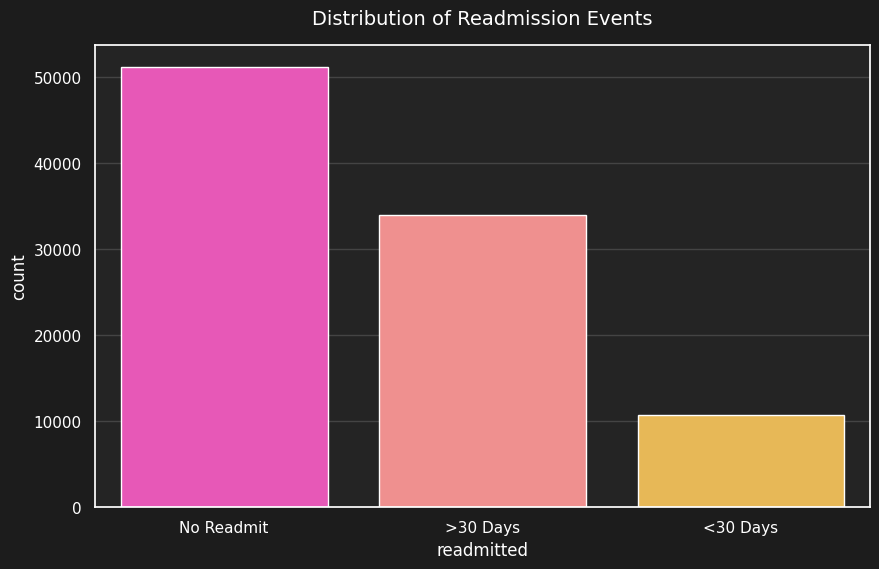

In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_c, x='readmitted', palette='spring')
plt.title('Distribution of Readmission Events', color='white', fontsize=14, pad=15)
ax.set_xticklabels(['No Readmit', '>30 Days', '<30 Days'])
plt.show()

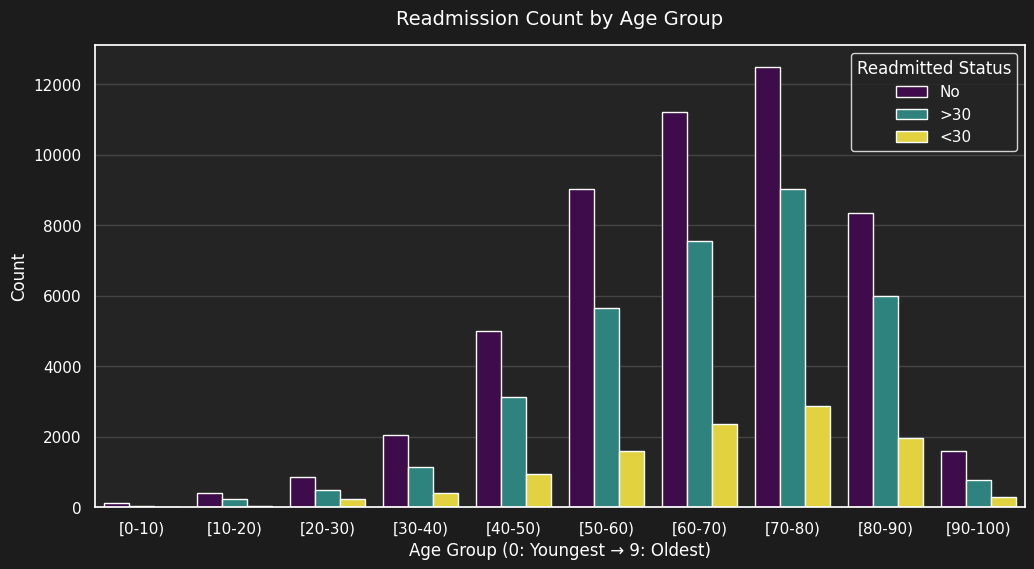

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_c, x='age', hue='readmitted', palette='viridis')
plt.title('Readmission Count by Age Group', color='white', fontsize=14, pad=15)
plt.xlabel('Age Group (0: Youngest → 9: Oldest)', color='white')
plt.ylabel('Count', color='white')
legend = plt.legend(title='Readmitted Status', labels=['No', '>30', '<30'],
                    facecolor='#242424', edgecolor='white')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')
plt.show()

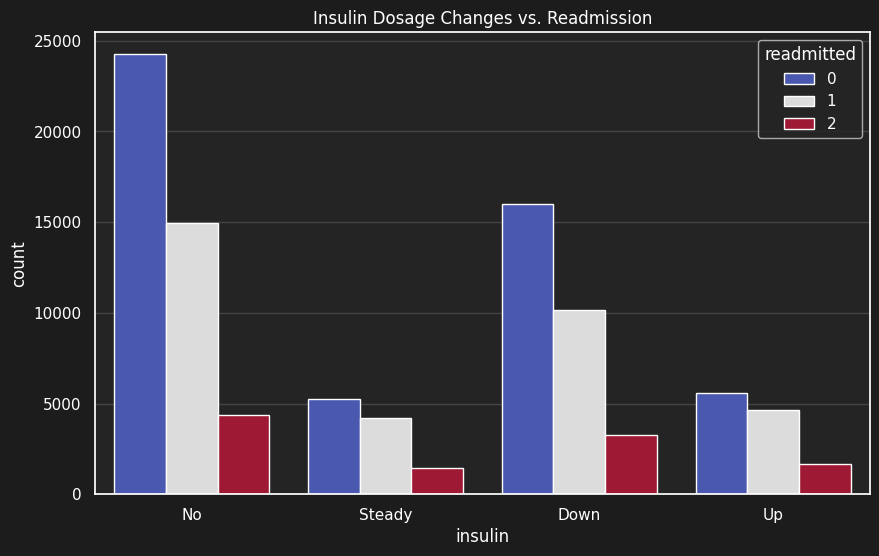

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_c, x='insulin', hue='readmitted', palette='coolwarm')
plt.title('Insulin Dosage Changes vs. Readmission')
plt.xticks([0, 1, 2, 3], ['No', 'Steady', 'Down', 'Up'])
plt.show()

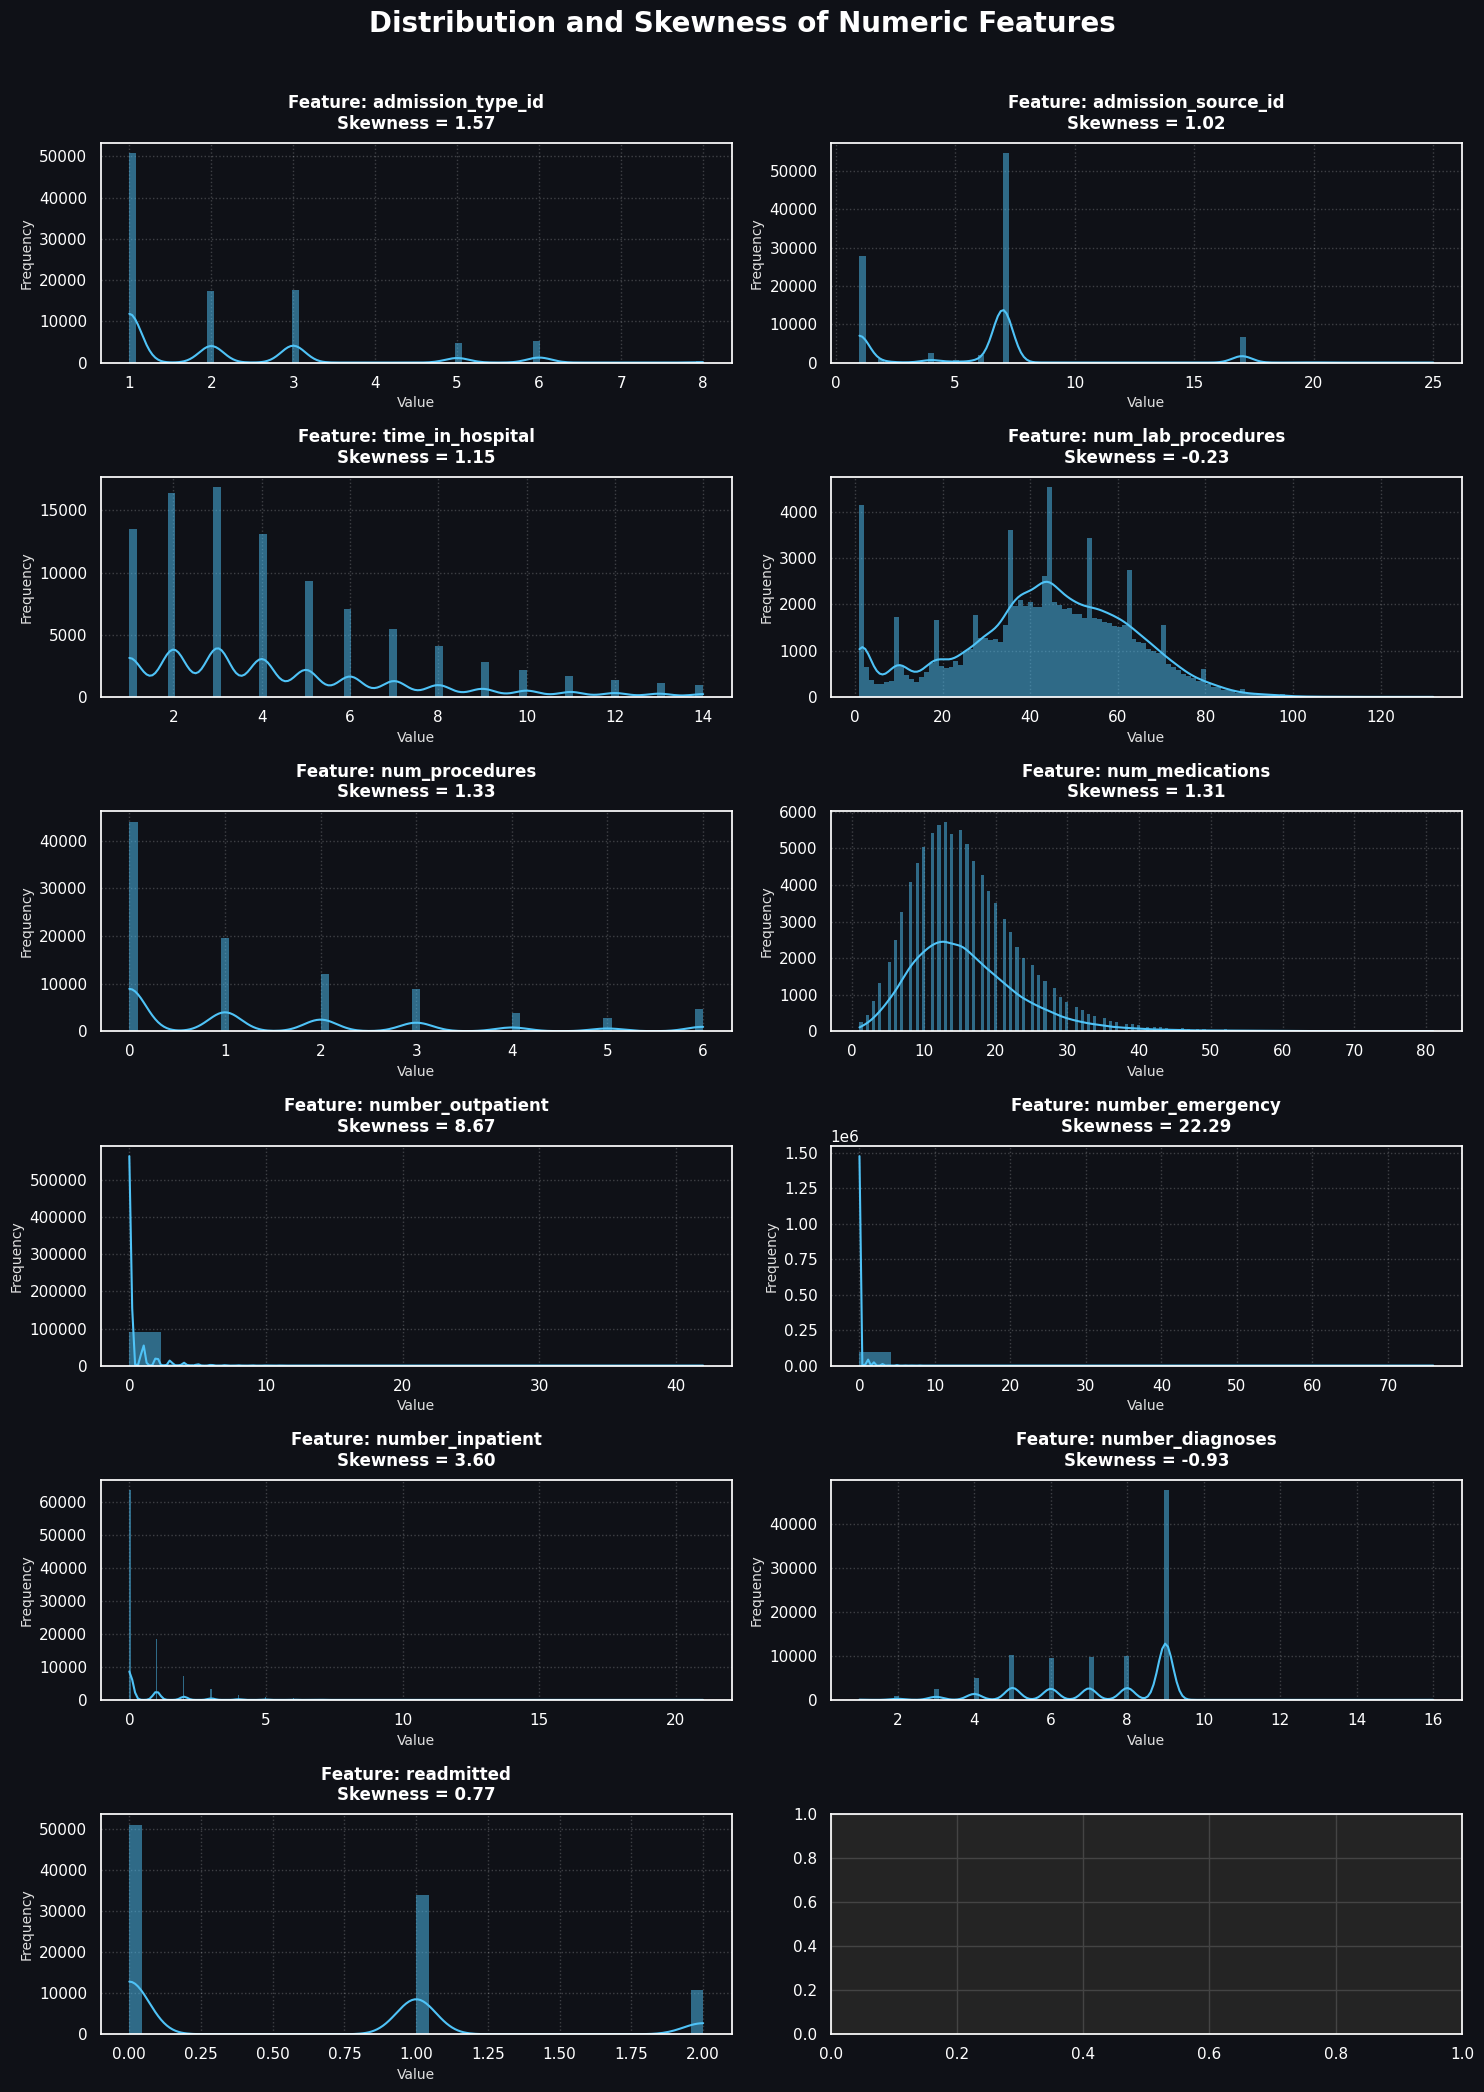

In [15]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 22))
fig.set_facecolor('#0f1117')
axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    if i >= len(axes_flat):
        break
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')
    skew_val = df_c[col].skew()
    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)
    ax.set_title(f"Feature: {col}\nSkewness = {skew_val:.2f}",
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel("Value", fontsize=10, color='#e0e0e0')
    ax.set_ylabel("Frequency", fontsize=10, color='#e0e0e0')
    ax.grid(True, linestyle=':', alpha=0.2, color='white')
    ax.tick_params(colors='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Distribution and Skewness of Numeric Features", color='white', fontsize=20, fontweight='bold')
plt.show()

In [16]:
cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient',
               'num_medications', 'time_in_hospital', 'num_lab_procedures']

for col in cols_to_fix:
    df_c[col] = np.log1p(df_c[col])

print('Skewness after Log Transformation:')
print(df_c[cols_to_fix].skew())


Skewness after Log Transformation:
number_emergency      3.546373
number_outpatient     2.668303
number_inpatient      1.433748
num_medications      -0.499344
time_in_hospital      0.111122
num_lab_procedures   -2.192645
dtype: float64


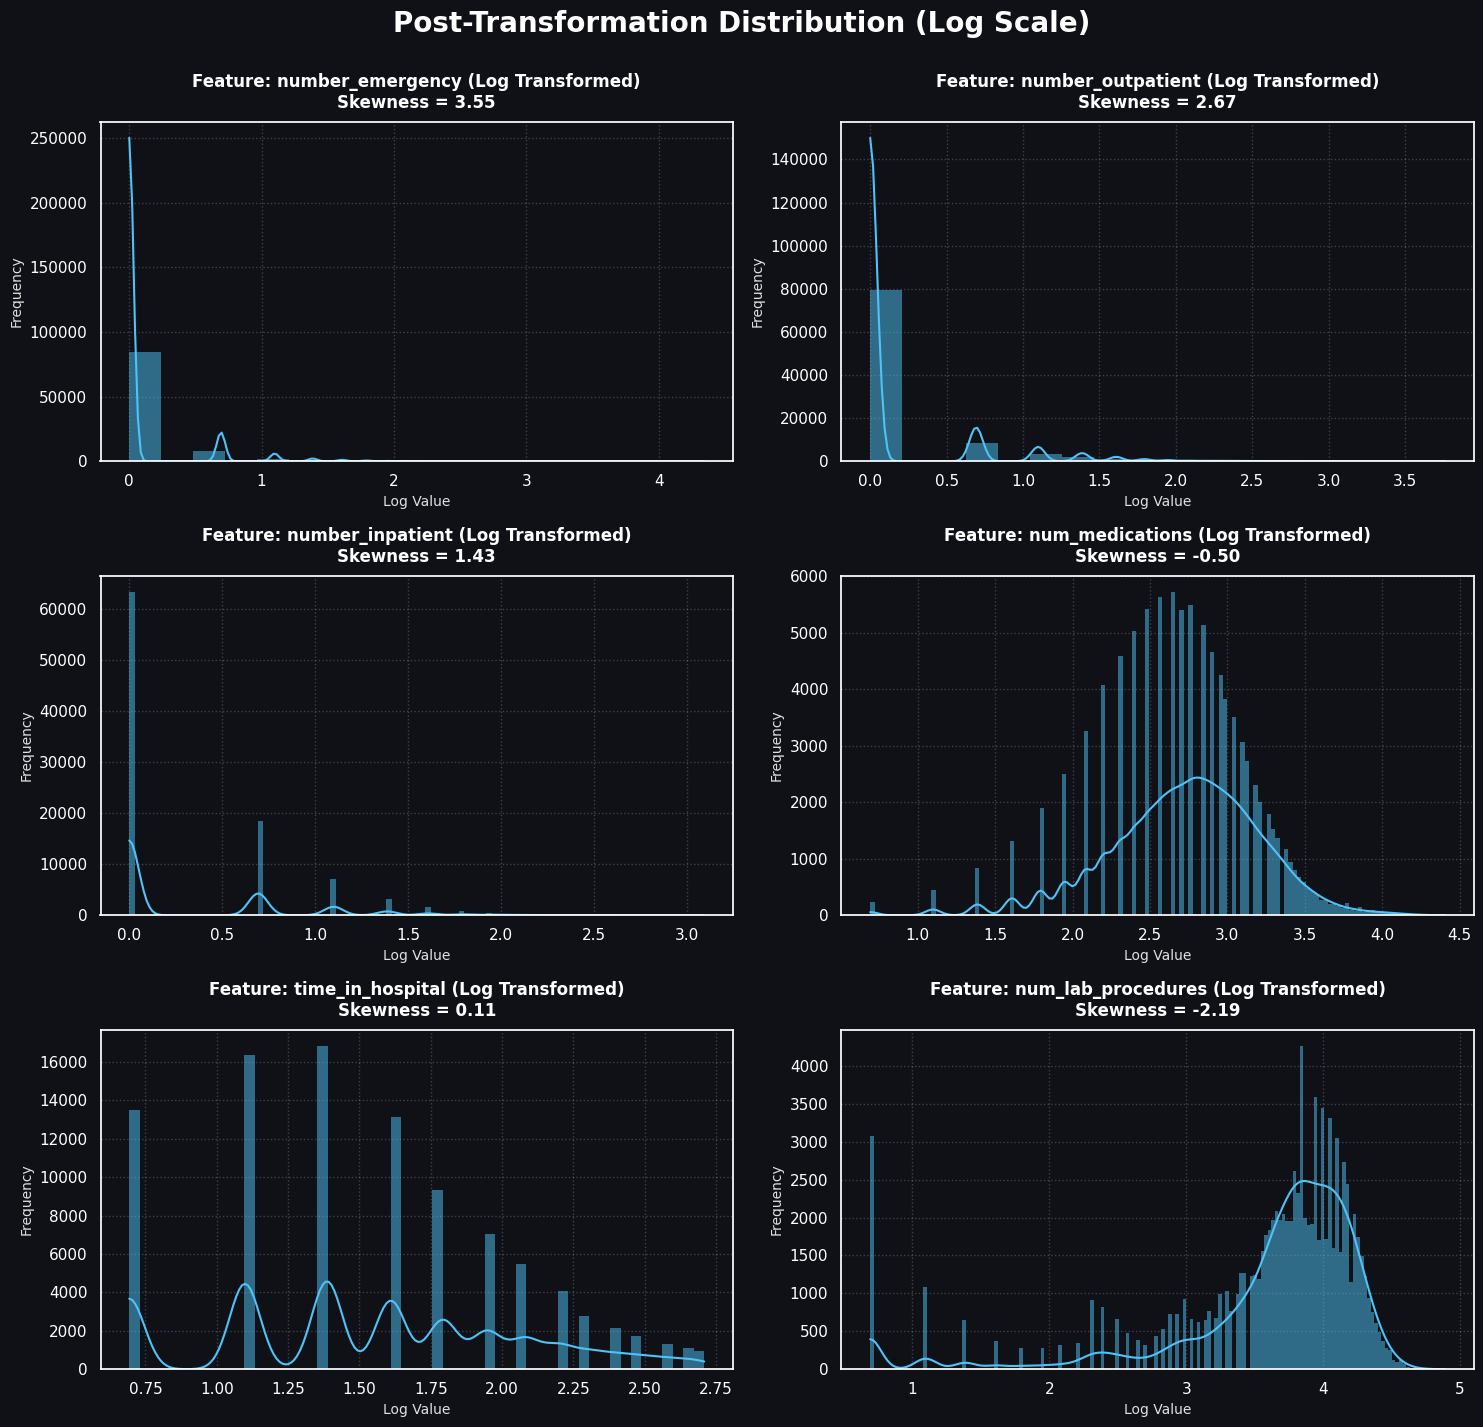

In [17]:
cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient',
               'num_medications', 'time_in_hospital', 'num_lab_procedures']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
fig.set_facecolor('#0f1117')
axes_flat = axes.flatten()

for i, col in enumerate(cols_to_fix):
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')
    skew_val = df_c[col].skew()
    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)
    ax.set_title(f'Feature: {col} (Log Transformed)\nSkewness = {skew_val:.2f}',
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel('Log Value', fontsize=10, color='#e0e0e0')
    ax.set_ylabel('Frequency', fontsize=10, color='#e0e0e0')
    ax.grid(True, linestyle=':', alpha=0.2, color='white')
    ax.tick_params(colors='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Post-Transformation Distribution (Log Scale)', color='white',
             fontsize=20, fontweight='bold')
plt.show()


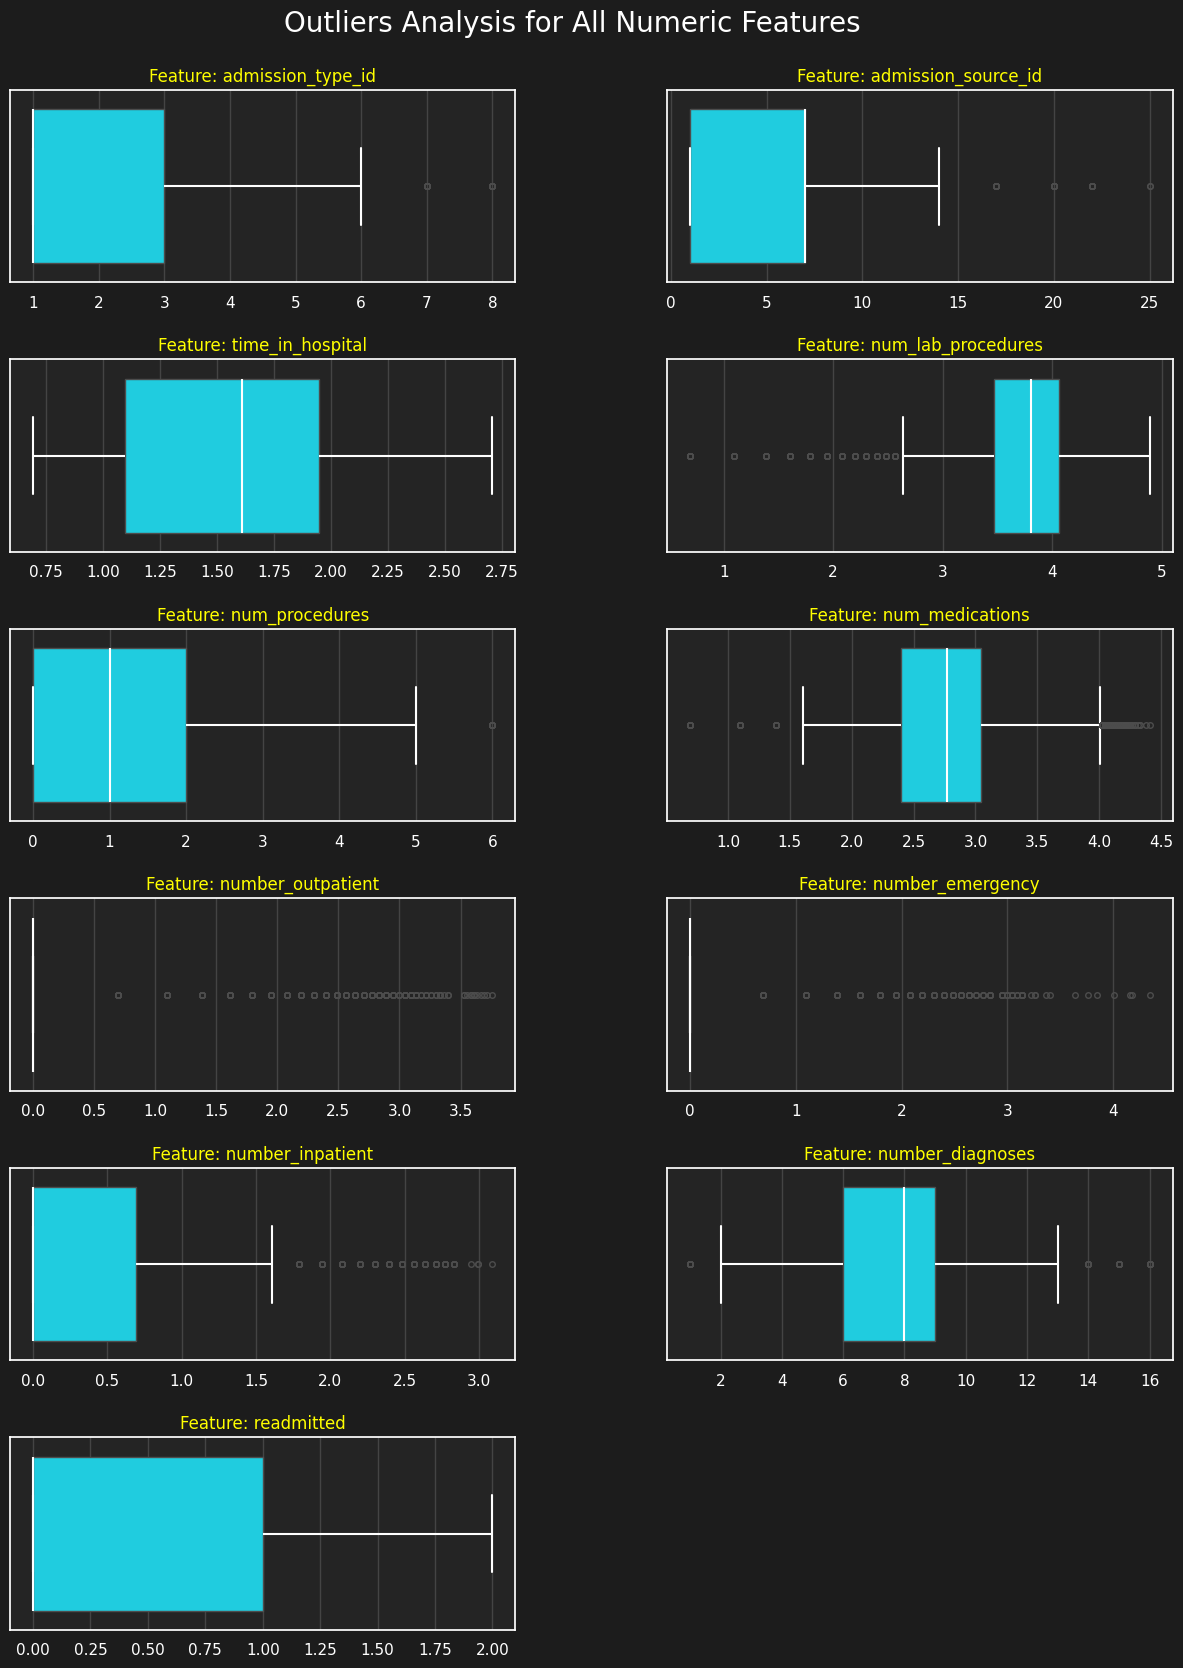

In [18]:
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Outliers Analysis for All Numeric Features', color='white', fontsize=20, y=0.92)
axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    ax = axes_flat[i]
    sns.boxplot(x=df_c[col], ax=ax, color='#00e5ff', fliersize=4)
    plt.setp(ax.artists, edgecolor="white", linewidth=1.5)
    plt.setp(ax.lines, color="white", linewidth=1.5)
    ax.set_title(f'Feature: {col}', color='yellow', fontsize=12)
    ax.set_xlabel('')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.show()

In [19]:
print(f"{'Feature':<25} | {'Outliers Count':<15} | {'Percentage':<10}")
print("-" * 55)
total_rows = len(df_c)

for col in df_num:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_c[(df_c[col] < lower_bound) | (df_c[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / total_rows) * 100
    print(f"{col:<25} | {count:<15} | {percentage:.2f}%")

Feature                   | Outliers Count  | Percentage
-------------------------------------------------------
admission_type_id         | 337             | 0.35%
admission_source_id       | 6866            | 7.17%
time_in_hospital          | 0               | 0.00%
num_lab_procedures        | 9246            | 9.65%
num_procedures            | 4582            | 4.78%
num_medications           | 1770            | 1.85%
number_outpatient         | 16389           | 17.10%
number_emergency          | 11272           | 11.76%
number_inpatient          | 1960            | 2.05%
number_diagnoses          | 261             | 0.27%
readmitted                | 0               | 0.00%


In [20]:
safe_cols_to_clean = [ 'num_lab_procedures', 'num_medications', 'number_diagnoses', 'time_in_hospital']
print(f"Original shape: {df_c.shape}")

for col in safe_cols_to_clean:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_c = df_c[(df_c[col] >= lower_bound) & (df_c[col] <= upper_bound)]

print(f"Fixed shape: {df_c.shape}")

Original shape: (95818, 27)
Fixed shape: (84886, 27)


In [21]:
print(f"{'Feature':<25} | {'Outliers Count':<15} | {'Percentage':<10}")
print("-" * 55)
total_rows = len(df_c)

for col in df_num:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_c[(df_c[col] < lower_bound) | (df_c[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / total_rows) * 100
    print(f"{col:<25} | {count:<15} | {percentage:.2f}%")

Feature                   | Outliers Count  | Percentage
-------------------------------------------------------
admission_type_id         | 286             | 0.34%
admission_source_id       | 6026            | 7.10%
time_in_hospital          | 0               | 0.00%
num_lab_procedures        | 1639            | 1.93%
num_procedures            | 4131            | 4.87%
num_medications           | 0               | 0.00%
number_outpatient         | 14325           | 16.88%
number_emergency          | 10104           | 11.90%
number_inpatient          | 1800            | 2.12%
number_diagnoses          | 0               | 0.00%
readmitted                | 0               | 0.00%


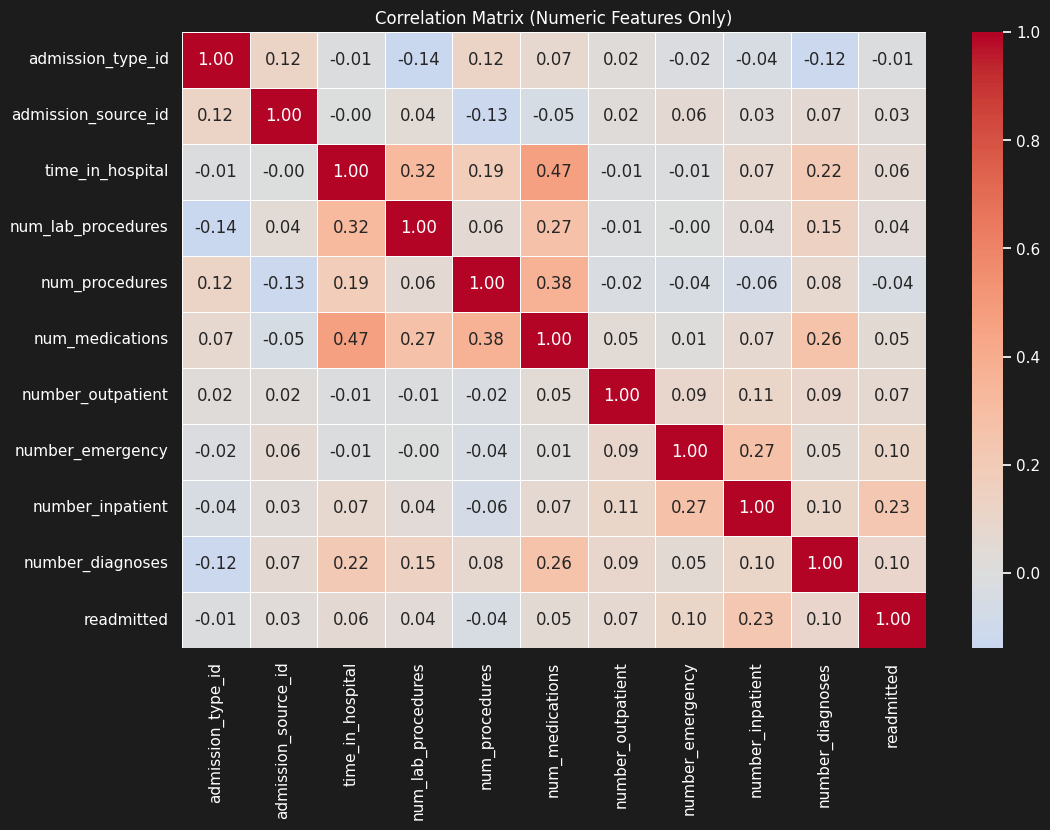

readmitted             1.000000
number_inpatient       0.233497
number_emergency       0.104288
number_diagnoses       0.100961
number_outpatient      0.067485
time_in_hospital       0.057634
num_medications        0.054058
num_lab_procedures     0.036428
admission_source_id    0.028534
admission_type_id     -0.008632
num_procedures        -0.036341
Name: readmitted, dtype: float64


In [22]:
corr_matrix = df_num.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True,
            fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

corr_with_target = corr_matrix['readmitted'].sort_values(ascending=False)
print(corr_with_target)
# need to drop  admission_type_id  &&  num_procedures

#**Feature Engineering/Selection**
----------------------------------------------------------------------------------------
--------------------------------------------------------------------


In [23]:
age_dummies = pd.get_dummies(
    df_c['age'],
    prefix='age',
    drop_first=False
)

age_dummies = age_dummies.astype(int)

df_c = df_c.drop(columns=['age'])
df_c = pd.concat([df_c, age_dummies], axis=1)


In [24]:
df_c = df_c.drop(columns=['admission_type_id', 'num_procedures'])

In [25]:
cat_cols = ['race', 'gender', 'change', 'diabetesMed',
            'discharge_group', 'diag_1', 'diag_2', 'diag_3']
df_c = pd.get_dummies(df_c, columns=cat_cols, drop_first=True)

In [26]:
df_c['admission_source_id'] = df_c['admission_source_id'].astype(str)
df_c = pd.get_dummies(df_c, columns=['admission_source_id'], drop_first=True)

In [27]:
drop_cols = [
    'admission_source_id_8',
    'admission_source_id_9',
    'admission_source_id_10',
    'admission_source_id_11',
    'admission_source_id_13',
    'admission_source_id_14',
    'admission_source_id_22',
    'admission_source_id_25',
    'diag_1_External_Causes',
    'diag_1_Other',
    'diag_1_Congenital',
    'diag_2_Congenital',
    'diag_3_Congenital',
]
# errors='ignore' silently skips any column that doesn't exist in this run
df_c = df_c.drop(columns=drop_cols, errors='ignore')


In [28]:
cats = df_c.select_dtypes(include='object').columns.tolist()
for col in cats:
    print(col, df_c[col].unique())

metformin ['No' 'Steady' 'Up' 'Down']
glimepiride ['No' 'Steady' 'Down' 'Up']
glipizide ['No' 'Steady' 'Up' 'Down']
glyburide ['No' 'Steady' 'Up' 'Down']
pioglitazone ['No' 'Steady' 'Up' 'Down']
rosiglitazone ['No' 'Steady' 'Up' 'Down']
insulin ['Up' 'Steady' 'No' 'Down']


In [29]:
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin','glimepiride','glipizide',
            'glyburide','pioglitazone','rosiglitazone','insulin']
for col in med_cols:
    df_c[col] = df_c[col].map(med_map)

In [30]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84886 entries, 1 to 101764
Data columns (total 97 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time_in_hospital           84886 non-null  float64
 1   num_lab_procedures         84886 non-null  float64
 2   num_medications            84886 non-null  float64
 3   number_outpatient          84886 non-null  float64
 4   number_emergency           84886 non-null  float64
 5   number_inpatient           84886 non-null  float64
 6   number_diagnoses           84886 non-null  int64  
 7   metformin                  84886 non-null  int64  
 8   glimepiride                84886 non-null  int64  
 9   glipizide                  84886 non-null  int64  
 10  glyburide                  84886 non-null  int64  
 11  pioglitazone               84886 non-null  int64  
 12  rosiglitazone              84886 non-null  int64  
 13  insulin                    84886 non-null  int64  

In [31]:
for col in df_c.columns:
    print("="*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_c[col].value_counts(dropna=False))
    print("\n")

Column: time_in_hospital
--------------------------------------------------
time_in_hospital
1.386294    14708
1.098612    13823
1.609438    12035
0.693147    10452
1.791759     8753
1.945910     6620
2.079442     5173
2.197225     3831
2.302585     2637
2.397895     2037
2.484907     1624
2.564949     1255
2.639057     1042
2.708050      896
Name: count, dtype: int64


Column: num_lab_procedures
--------------------------------------------------
num_lab_procedures
3.784190    2560
3.806662    2280
3.828641    2179
3.663562    2038
3.850148    2017
            ... 
4.795791       1
4.890349       1
4.804021       1
4.844187       1
4.779123       1
Name: count, Length: 106, dtype: int64


Column: num_medications
--------------------------------------------------
num_medications
2.639057    5070
2.564949    4969
2.772589    4963
2.708050    4840
2.484907    4727
2.833213    4671
2.397895    4388
2.890372    4271
2.944439    3973
2.302585    3929
2.995732    3569
2.197225    3460
3.04452

## Step 1 — Prepare Data

In [32]:
TARGET = 'readmitted'

X = df_c.drop(columns=[TARGET])
y = df_c[TARGET]

# Clean feature names (LightGBM dislikes '[', ']', '<')
X.columns = (
    X.columns
     .str.replace('[', '', regex=False)
     .str.replace(']', '', regex=False)
     .str.replace('<', 'lt', regex=False)
)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype('int8')
X = X.select_dtypes(include=[np.number])

# Drop columns with fewer than 300 positive samples — too sparse to learn from
sparse_cols = [c for c in X.columns if X[c].sum() < 300]
X = X.drop(columns=sparse_cols)
print(f'Dropped {len(sparse_cols)} sparse columns: {sparse_cols}')

print(f'Feature matrix shape : {X.shape}')
print(f'Class distribution   :')
print(y.value_counts().rename({0: 'No Readmit (0)',
                                 1: '>30 Days (1)',
                                 2: '<30 Days (2)'}))


Dropped 8 sparse columns: ['age_0-10)', 'diag_1_Sensory', 'diag_2_Other', 'diag_2_Sensory', 'diag_3_Pregnancy', 'diag_3_Sensory', 'admission_source_id_20', 'admission_source_id_3']
Feature matrix shape : (84886, 88)
Class distribution   :
readmitted
No Readmit (0)    44772
>30 Days (1)      30442
<30 Days (2)       9672
Name: count, dtype: int64


## Step 1b — Feature Selection

Three complementary filter-based methods are applied:

**1. Correlation-based removal (manual):** `admission_type_id` and `num_procedures` were dropped after the correlation matrix showed near-zero correlation with `readmitted` (|r| < 0.02).

**2. Sparse column drop:** Dummy columns whose positive-class count is below 300 out of ~93,000 rows carry no reliable signal and are removed (e.g. `age_[0-10)` with only 98 rows).

**3. Variance Threshold (filter method):** Removes near-constant features where one value dominates ≥ 99% of rows — these add noise without discriminative power.

XGBoost does its own internal embedded feature selection via tree splits, so aggressive wrapper/MI methods are not needed and were found empirically to reduce test accuracy.

Variance Threshold removed 8 near-constant features:
  - age_10-20)
  - race_Asian
  - discharge_group_Hospice
  - diag_1_Nervous_System
  - diag_1_Pregnancy
  - diag_2_External_Causes
  - diag_2_Pregnancy
  - admission_source_id_5

Final feature matrix shape: (84886, 80)


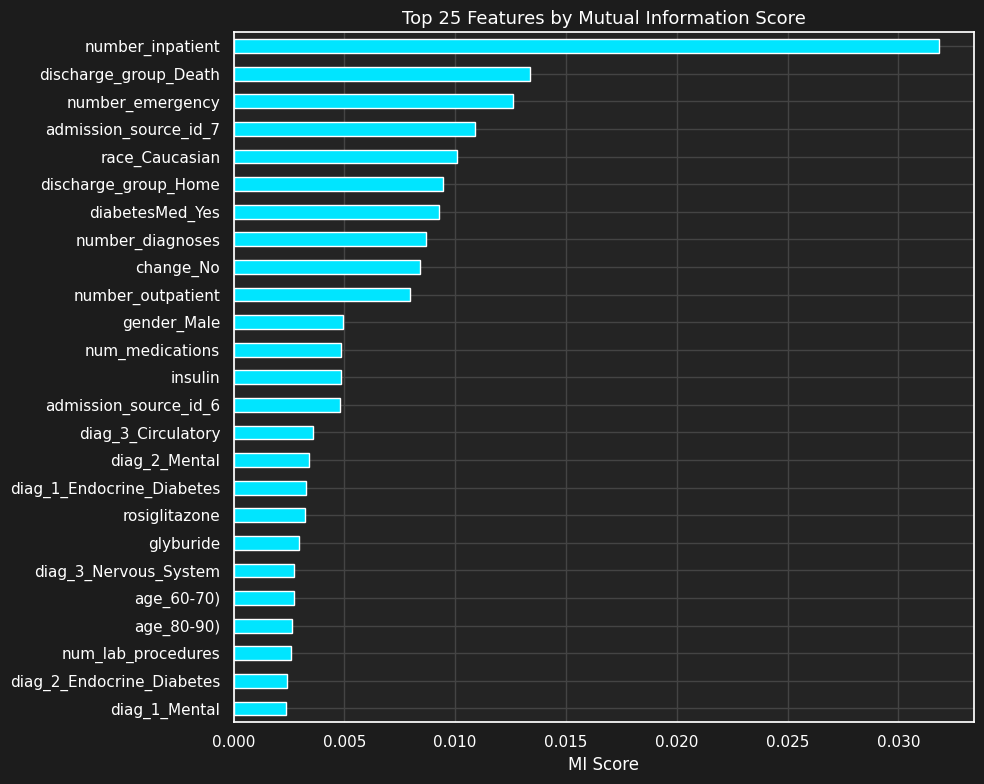

Top 5 features by MI: ['number_inpatient', 'discharge_group_Death', 'number_emergency', 'admission_source_id_7', 'race_Caucasian']


In [33]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.99 * (1 - 0.99))
vt.fit(X)

low_var_cols = X.columns[~vt.get_support()].tolist()
X = X[X.columns[vt.get_support()]]

print(f'Variance Threshold removed {len(low_var_cols)} near-constant features:')
for c in low_var_cols:
    print(f'  - {c}')
print(f'\nFinal feature matrix shape: {X.shape}')

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#242424')
mi_series[::-1].plot(kind='barh', ax=ax, color='#00e5ff')
ax.set_title('Top 25 Features by Mutual Information Score', color='white', fontsize=13)
ax.set_xlabel('MI Score', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig('mi_scores_XGB.png', facecolor='#1c1c1c')
plt.show()
print('Top 5 features by MI:', mi_series.head(5).index.tolist())


## Step 2 — Train / Test Split (80 / 20)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]:,} rows')
print(f'Test  size : {X_test.shape[0]:,} rows')
print(f'\nClass distribution (train):')
print(y_train.value_counts().rename({0:'No Readmit',1:'>30 Days',2:'<30 Days'}))


Train size : 67,908 rows
Test  size : 16,978 rows

Class distribution (train):
readmitted
No Readmit    35817
>30 Days      24353
<30 Days       7738
Name: count, dtype: int64


## Step 3 — Scale Continuous Features


In [35]:
candidate_num_cols = ['time_in_hospital', 'num_lab_procedures',
                      'num_medications', 'number_outpatient', 'number_emergency',
                      'number_inpatient', 'number_diagnoses']
num_cols = [c for c in candidate_num_cols if c in X_train.columns]
print(f'Scaling {len(num_cols)} continuous columns: {num_cols}')

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled.loc[:, num_cols]  = scaler.transform(X_test[num_cols])


Scaling 7 continuous columns: ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


## Step 4 — LightGBM Model Training

In [36]:
CLASS_NAMES = ['No Readmit', '>30 Days', '<30 Days']

best_lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

best_lgbm.fit(X_train_scaled, y_train)
print('LightGBM trained ✓')

joblib.dump(best_lgbm, 'best_lgbm_model.pkl')

best_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
}
with open('best_lgbm_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)

joblib.dump(scaler, 'scaler.pkl')
print(' Saved: best_lgbm_model.pkl')
print(' Saved: best_lgbm_params.json')
print(' Saved: scaler.pkl')


LightGBM trained ✓
 Saved: best_lgbm_model.pkl
 Saved: best_lgbm_params.json
 Saved: scaler.pkl


In [37]:
for name, (X_eval, y_eval) in [('Training', (X_train_scaled, y_train)),
                                 ('Testing',  (X_test_scaled,  y_test))]:
    y_pred = best_lgbm.predict(X_eval)
    print(f"\n{'='*40}")
    print(f"Phase: {name}")
    print(f"Accuracy:  {accuracy_score(y_eval, y_pred):.3f}")
    print(f"Precision: {precision_score(y_eval, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_eval, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_eval, y_pred, average='weighted'):.3f}")
    print('\nClassification Report:')
    print(classification_report(y_eval, y_pred, target_names=CLASS_NAMES))



Phase: Training
Accuracy:  0.587
Precision: 0.624
Recall:    0.587
F1 Score:  0.598

Classification Report:
              precision    recall  f1-score   support

  No Readmit       0.72      0.63      0.67     35817
    >30 Days       0.57      0.52      0.54     24353
    <30 Days       0.33      0.63      0.43      7738

    accuracy                           0.59     67908
   macro avg       0.54      0.59      0.55     67908
weighted avg       0.62      0.59      0.60     67908


Phase: Testing
Accuracy:  0.506
Precision: 0.546
Recall:    0.506
F1 Score:  0.521

Classification Report:
              precision    recall  f1-score   support

  No Readmit       0.67      0.59      0.63      8955
    >30 Days       0.47      0.42      0.45      6089
    <30 Days       0.20      0.37      0.26      1934

    accuracy                           0.51     16978
   macro avg       0.45      0.46      0.44     16978
weighted avg       0.55      0.51      0.52     16978



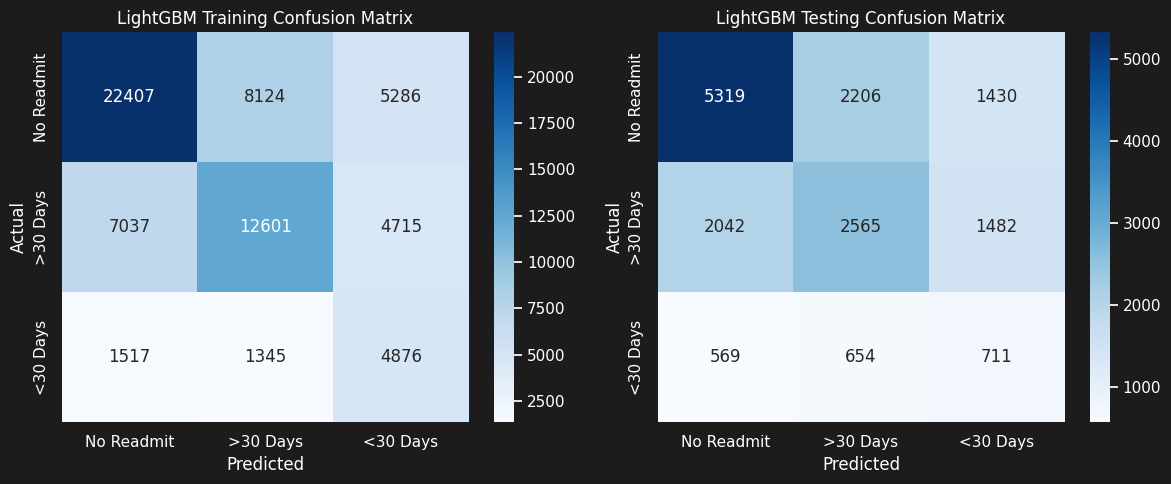

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, (X_eval, y_eval)) in zip(axes, [
    ('Training', (X_train_scaled, y_train)),
    ('Testing',  (X_test_scaled,  y_test))
]):
    cm = confusion_matrix(y_eval, best_lgbm.predict(X_eval))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f'LightGBM {name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_LGBM.png')
plt.show()


## Learning Curve & Validation Curve

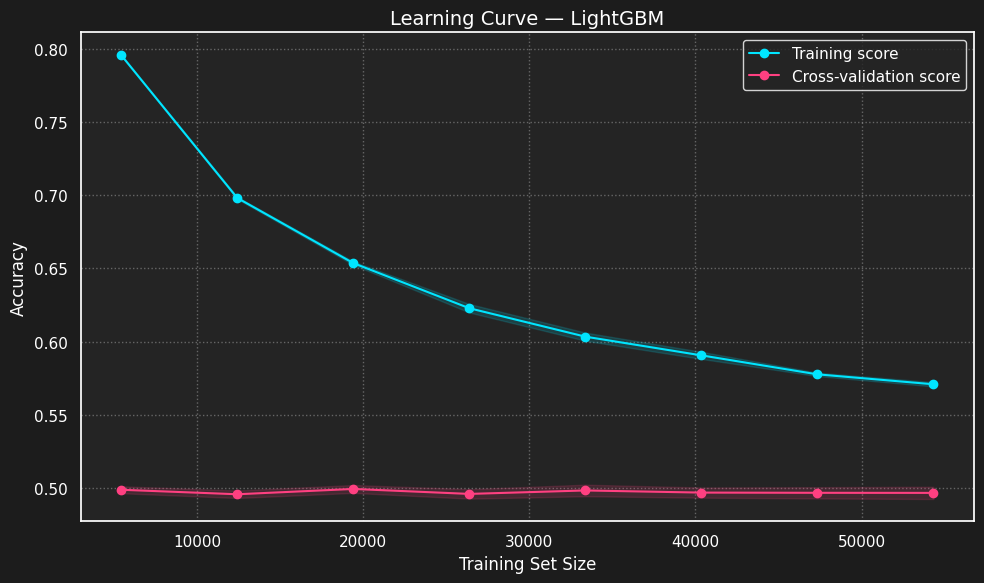

Final training accuracy : 0.571 ± 0.001
Final CV accuracy       : 0.497 ± 0.004
Bias-variance gap       : 0.074


In [39]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LGBMClassifier(
        objective='multiclass', num_class=3, n_estimators=300,
        learning_rate=0.05, max_depth=6, num_leaves=31,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    ),
    X_train_scaled, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#242424')

ax.plot(train_sizes, train_mean, 'o-', color='#00e5ff', label='Training score')
ax.fill_between(train_sizes, train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='#00e5ff')

ax.plot(train_sizes, val_mean, 'o-', color='#ff4081', label='Cross-validation score')
ax.fill_between(train_sizes, val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='#ff4081')

ax.set_title('Learning Curve — LightGBM', color='white', fontsize=14)
ax.set_xlabel('Training Set Size', color='white')
ax.set_ylabel('Accuracy', color='white')
ax.tick_params(colors='white')
ax.grid(True, linestyle=':', alpha=0.3, color='white')
legend = ax.legend(facecolor='#242424', edgecolor='white')
plt.setp(legend.get_texts(), color='white')
plt.tight_layout()
plt.savefig('learning_curve_LGBM.png', facecolor='#1c1c1c')
plt.show()

print(f'Final training accuracy : {train_mean[-1]:.3f} ± {train_std[-1]:.3f}')
print(f'Final CV accuracy       : {val_mean[-1]:.3f} ± {val_std[-1]:.3f}')
print(f'Bias-variance gap       : {train_mean[-1] - val_mean[-1]:.3f}')


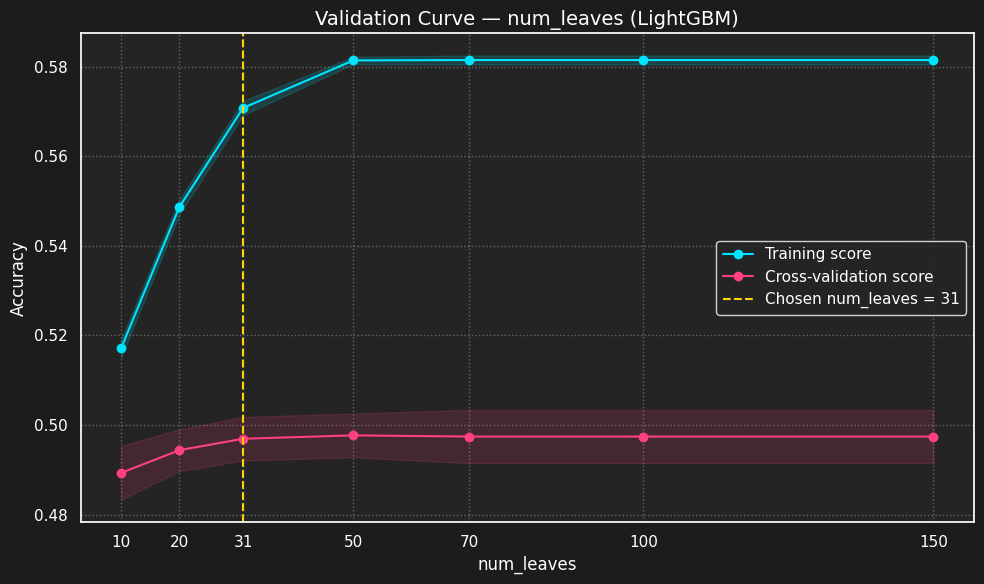

Best num_leaves by CV    : 50
CV accuracy at 50 leaves : 0.498


In [40]:
from sklearn.model_selection import validation_curve

param_range = [10, 20, 31, 50, 70, 100, 150]

train_scores_v, val_scores_v = validation_curve(
    LGBMClassifier(
        objective='multiclass', num_class=3, n_estimators=300,
        learning_rate=0.05, max_depth=6, feature_fraction=0.8,
        bagging_fraction=0.8, bagging_freq=5, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    ),
    X_train_scaled, y_train,
    param_name='num_leaves',
    param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean_v = train_scores_v.mean(axis=1)
train_std_v  = train_scores_v.std(axis=1)
val_mean_v   = val_scores_v.mean(axis=1)
val_std_v    = val_scores_v.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#242424')

ax.plot(param_range, train_mean_v, 'o-', color='#00e5ff', label='Training score')
ax.fill_between(param_range, train_mean_v - train_std_v,
                train_mean_v + train_std_v, alpha=0.15, color='#00e5ff')

ax.plot(param_range, val_mean_v, 'o-', color='#ff4081', label='Cross-validation score')
ax.fill_between(param_range, val_mean_v - val_std_v,
                val_mean_v + val_std_v, alpha=0.15, color='#ff4081')

ax.axvline(x=31, color='#ffd600', linestyle='--', linewidth=1.5, label='Chosen num_leaves = 31')

ax.set_title('Validation Curve — num_leaves (LightGBM)', color='white', fontsize=14)
ax.set_xlabel('num_leaves', color='white')
ax.set_ylabel('Accuracy', color='white')
ax.set_xticks(param_range)
ax.tick_params(colors='white')
ax.grid(True, linestyle=':', alpha=0.3, color='white')
legend = ax.legend(facecolor='#242424', edgecolor='white')
plt.setp(legend.get_texts(), color='white')
plt.tight_layout()
plt.savefig('validation_curve_LGBM.png', facecolor='#1c1c1c')
plt.show()

best_leaves = param_range[val_mean_v.argmax()]
print(f'Best num_leaves by CV    : {best_leaves}')
print(f'CV accuracy at {best_leaves} leaves : {val_mean_v.max():.3f}')


In [41]:
for name, (X_eval, y_eval) in [('Training', (X_train_scaled, y_train)),
                                 ('Testing',  (X_test_scaled,  y_test))]:
    y_prob = best_lgbm.predict_proba(X_eval)
    auc = roc_auc_score(y_eval, y_prob, multi_class='ovr')
    print(f'AUC {name}: {auc:.3f}')


AUC Training: 0.770
AUC Testing: 0.660


## XAI Technique 1 — SHAP

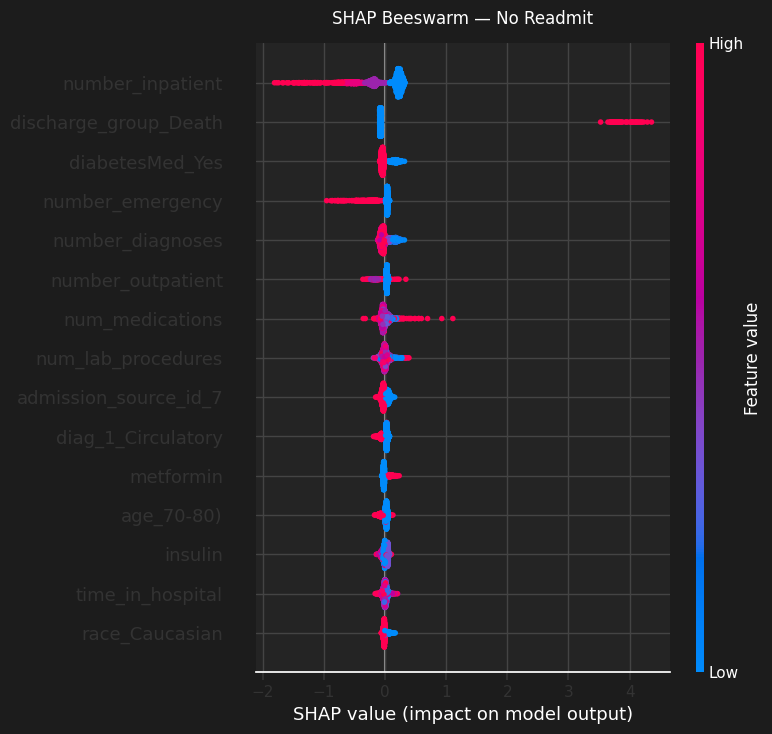

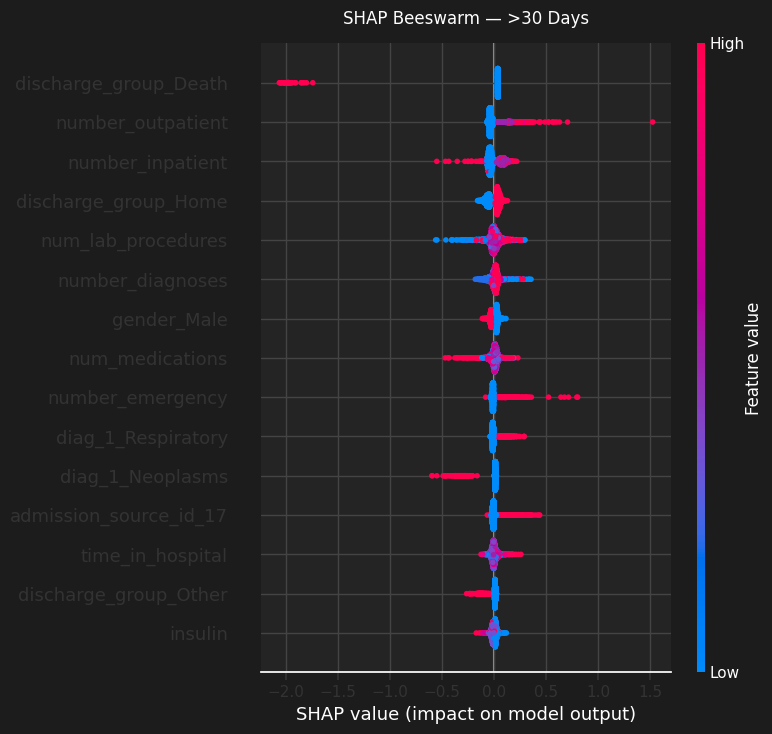

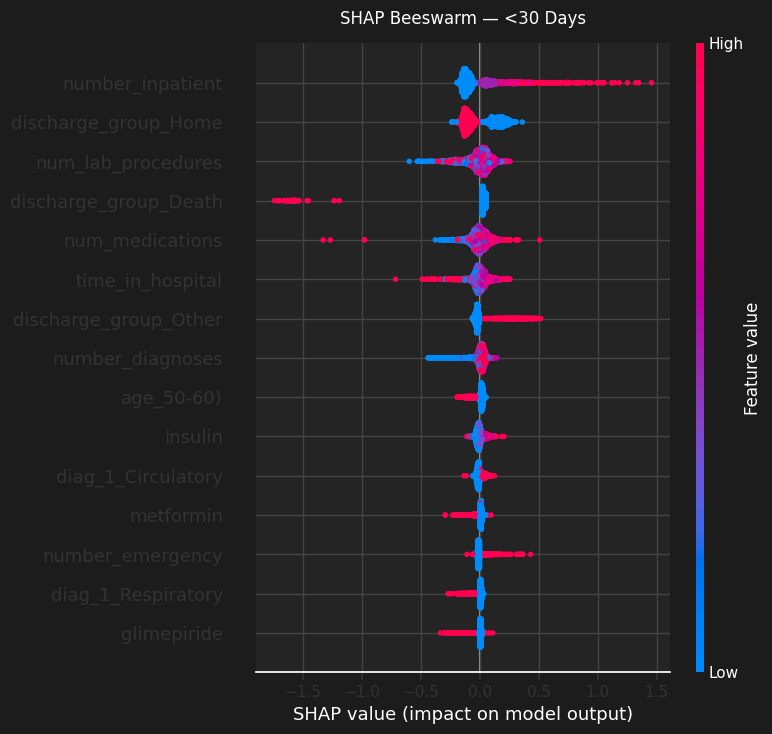

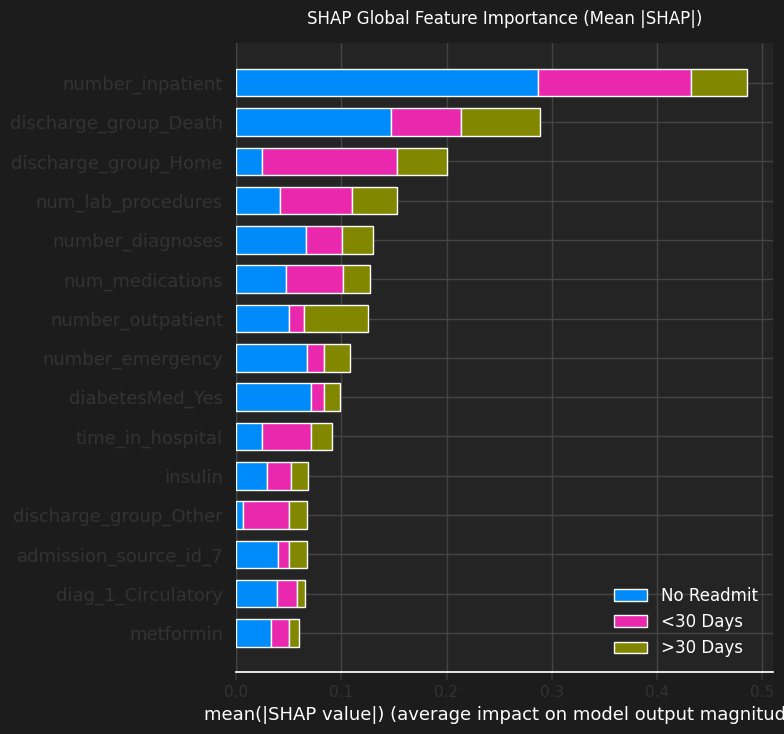

In [42]:


explainer = shap.TreeExplainer(best_lgbm)

sample_idx = np.random.choice(len(X_test_scaled), size=3000, replace=False)
X_shap = X_test_scaled.iloc[sample_idx].reset_index(drop=True)

shap_values = explainer.shap_values(X_shap)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    plt.figure()
    shap.summary_plot(
        shap_values[:, :, cls_idx],
        X_shap,
        plot_type='dot', show=False, max_display=15
    )
    plt.title(f'SHAP Beeswarm — {cls_name}', pad=14)
    plt.tight_layout()
    plt.savefig(f'shap_summary_class{cls_idx}_LGBM.png')
    plt.show()

plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type='bar', show=False,
    class_names=CLASS_NAMES, max_display=15
)
plt.title('SHAP Global Feature Importance (Mean |SHAP|)', pad=14)
plt.tight_layout()
plt.savefig('shap_bar_LGBM.png')
plt.show()


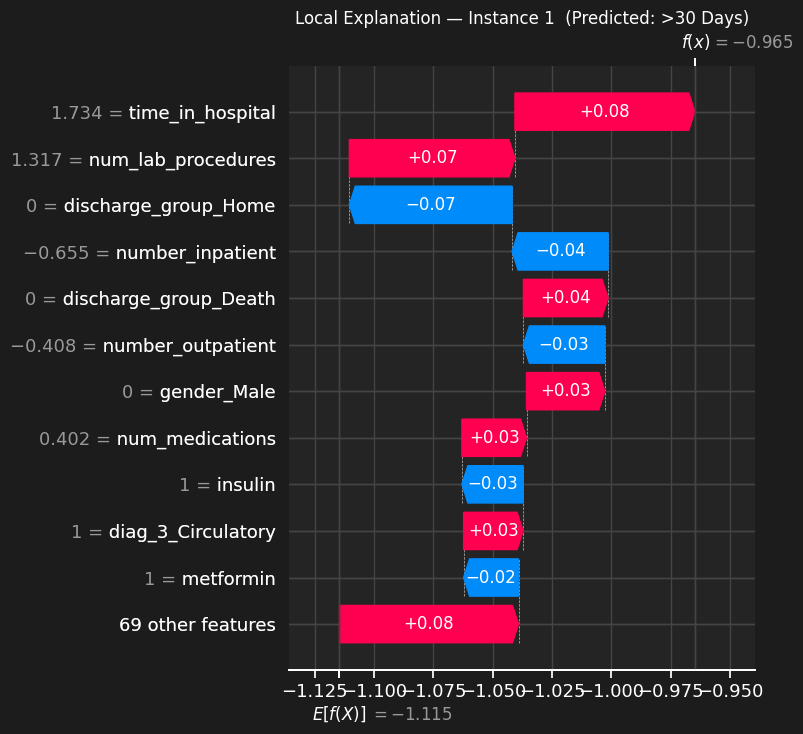

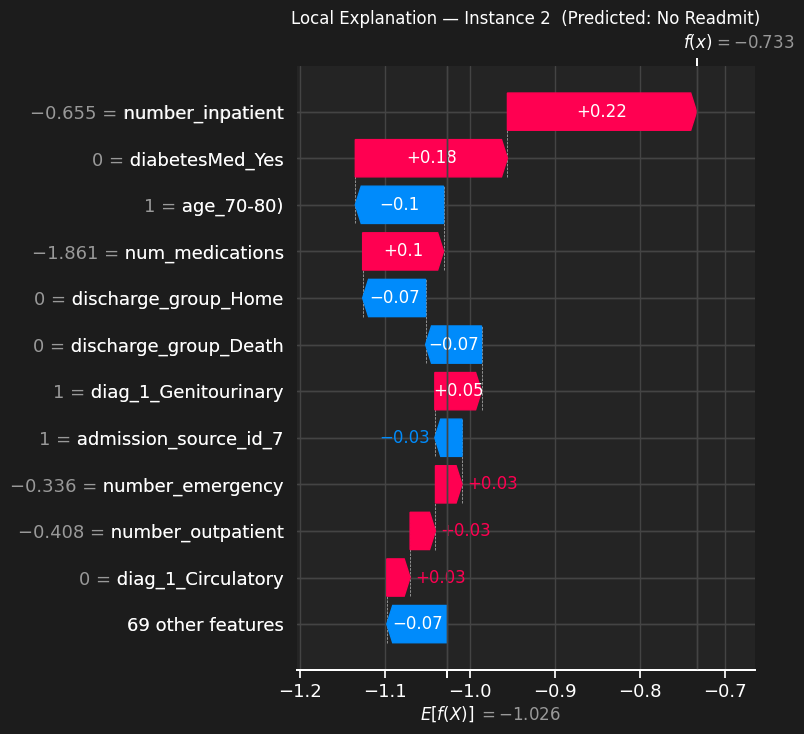

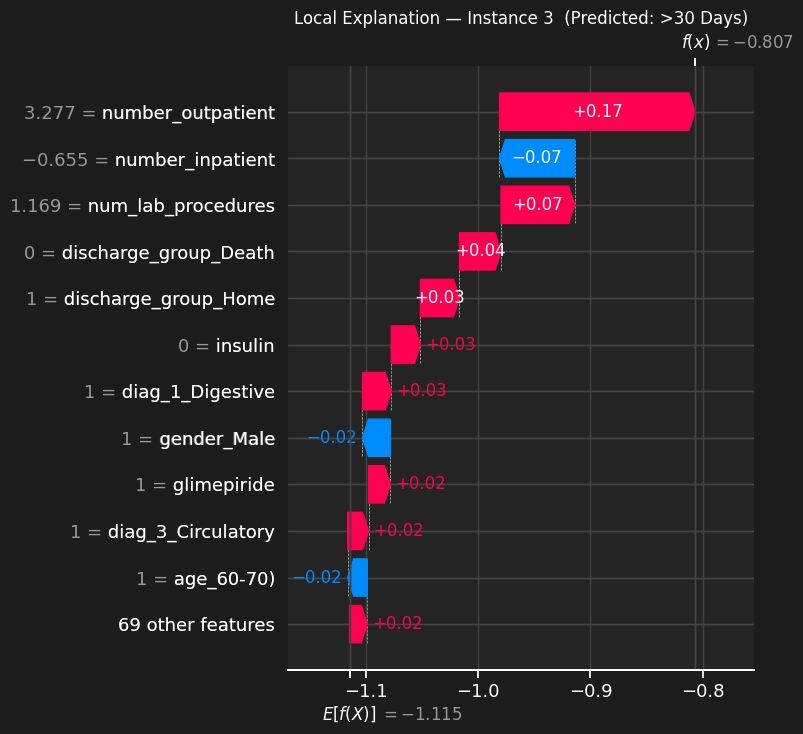

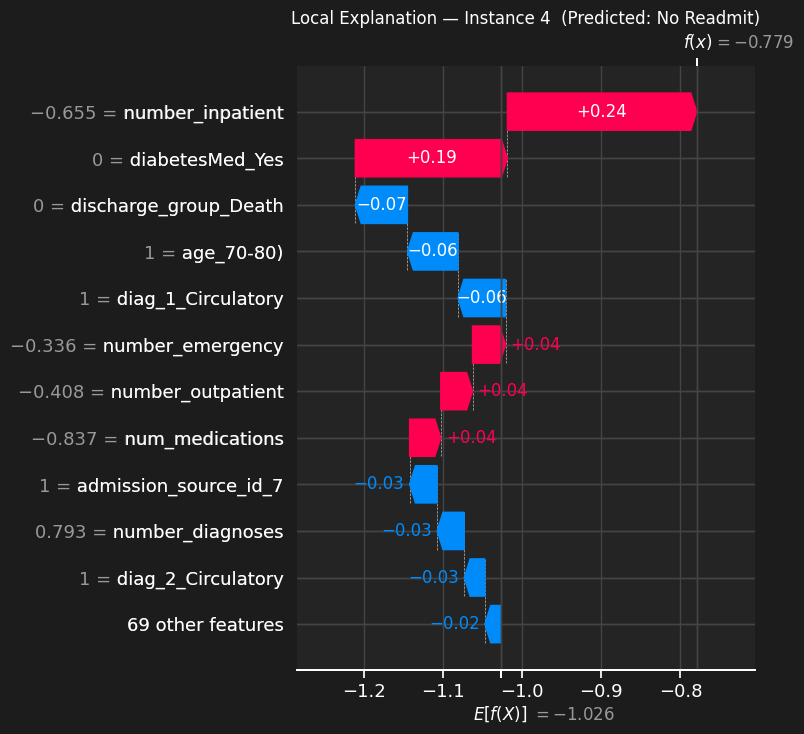

In [43]:


y_pred_test = best_lgbm.predict(X_shap)

for i in range(4):
    pred_cls = int(y_pred_test[i])
    plt.figure()
    shap.waterfall_plot(
        shap.Explanation(
            values       = shap_values[i, :, pred_cls],
            base_values  = explainer.expected_value[pred_cls],
            data         = X_shap.iloc[i],
            feature_names= X_shap.columns.tolist()
        ), show=False, max_display=12
    )
    plt.title(f'Local Explanation — Instance {i+1}  '
              f'(Predicted: {CLASS_NAMES[pred_cls]})')
    plt.tight_layout()
    plt.savefig(f'shap_local_instance_{i+1}_LGBM.png')
    plt.show()


## XAI Technique 2 — PDP (Partial Dependence Plots)

Top features for PDP: ['number_inpatient', 'discharge_group_Death', 'discharge_group_Home', 'num_lab_procedures', 'number_diagnoses', 'num_medications']


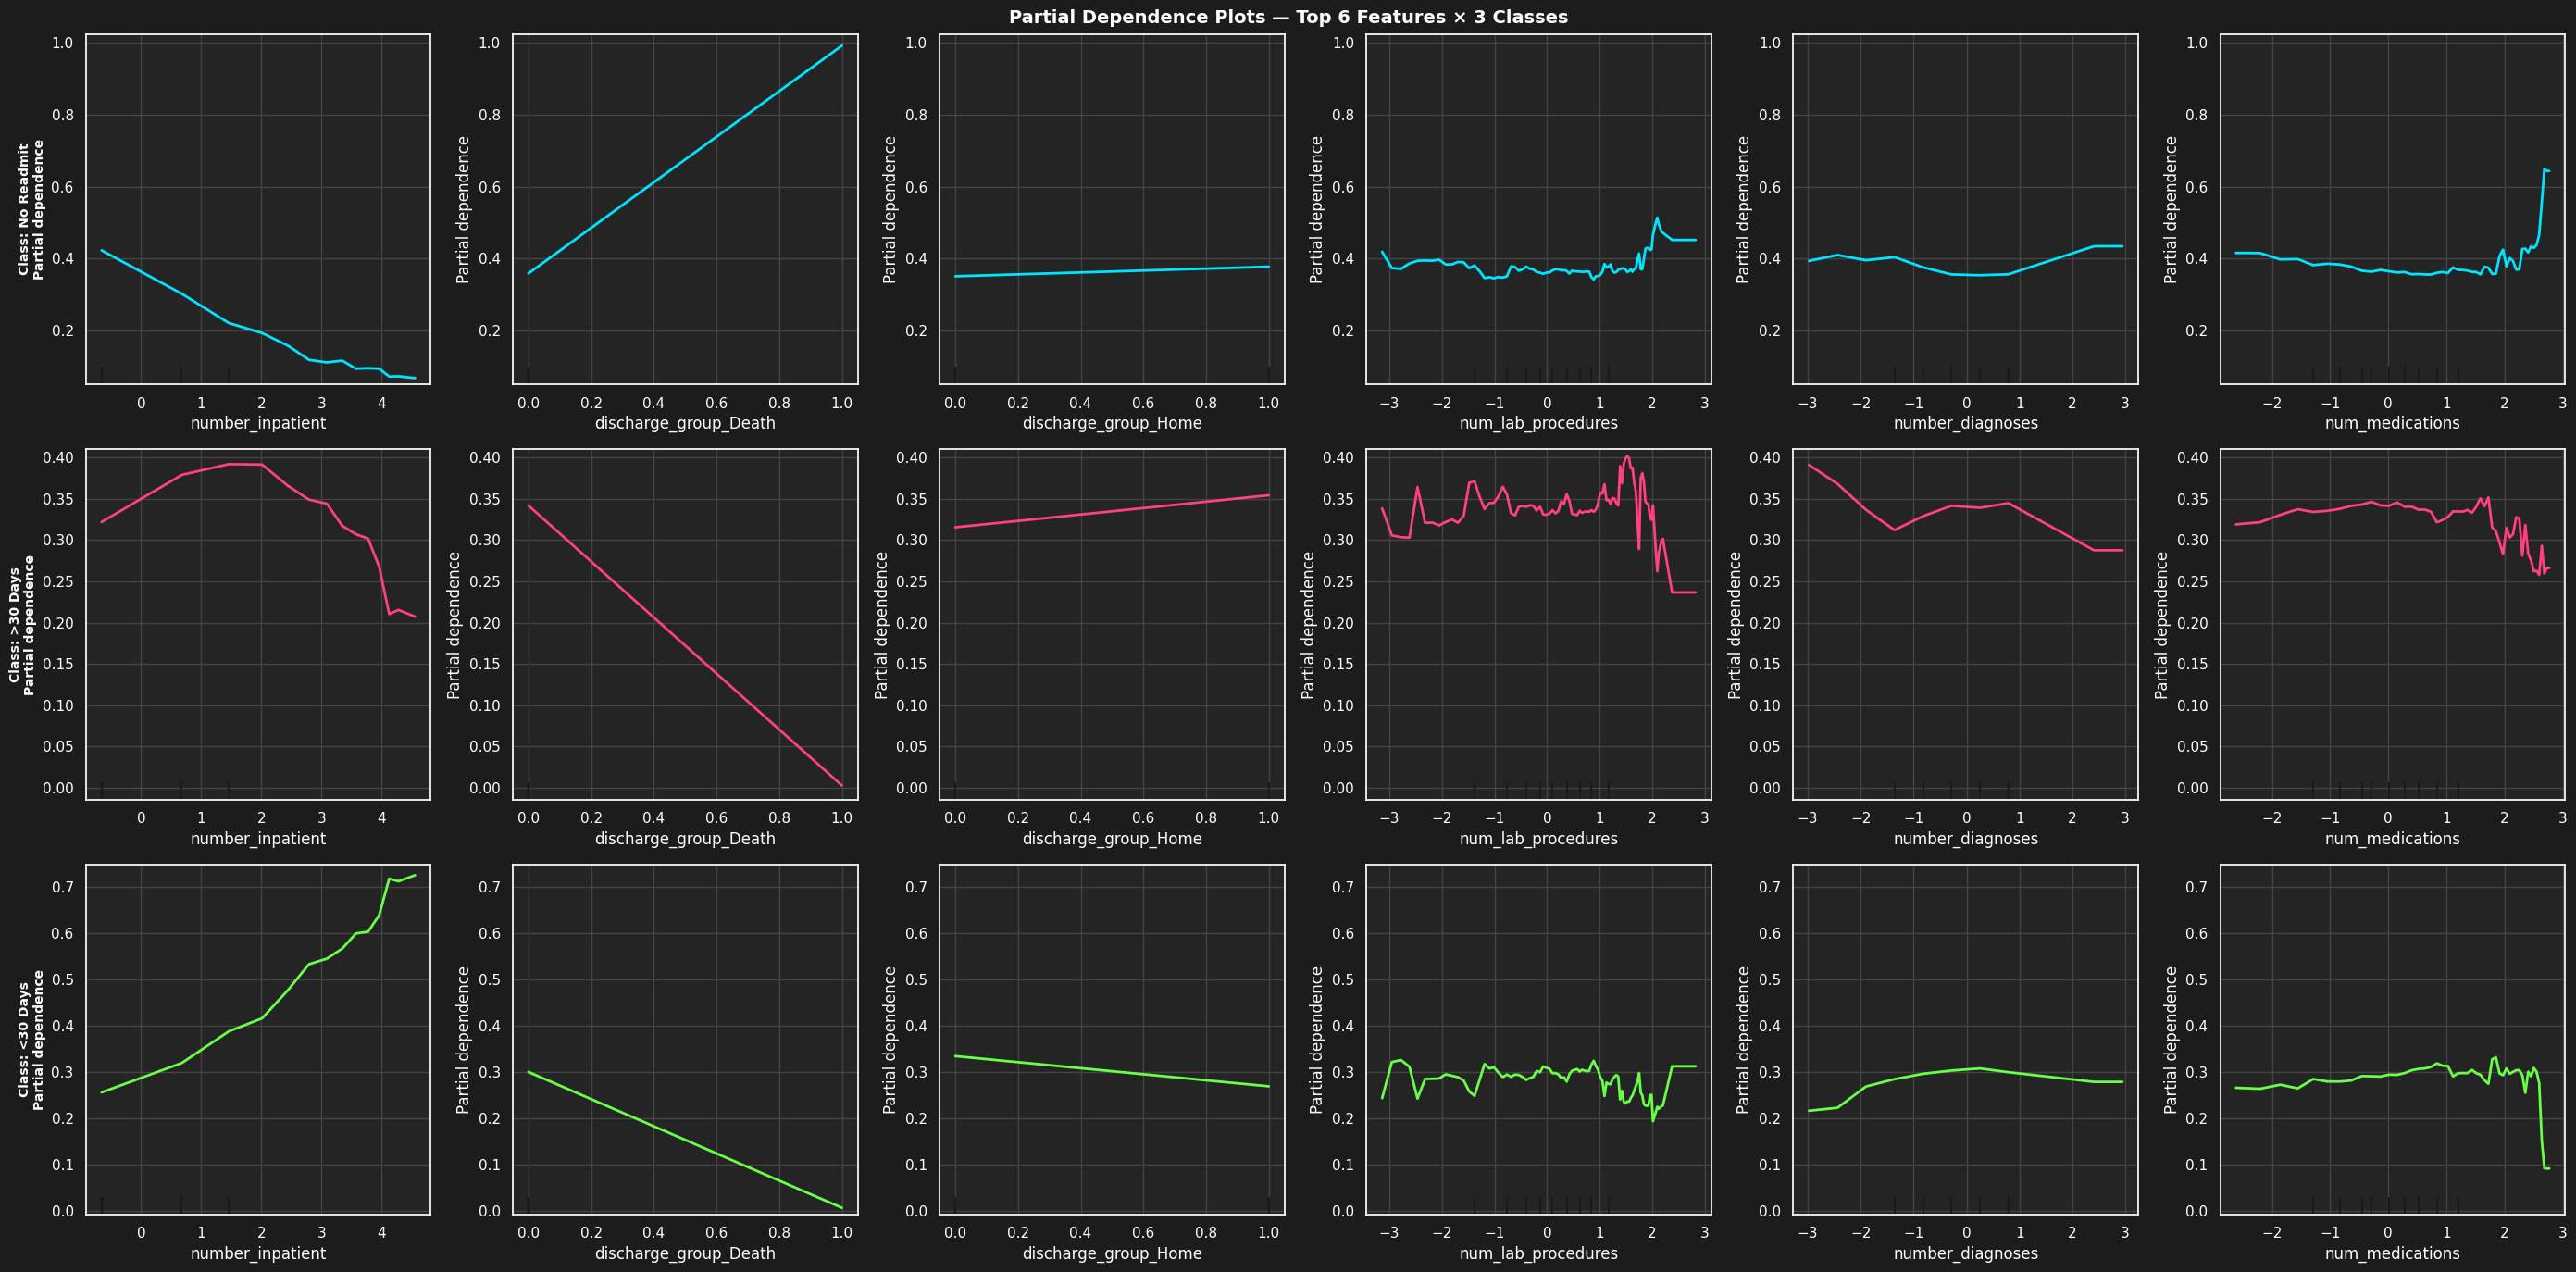

PDP saved ✓


In [44]:

global_shap_imp = np.array([np.abs(shap_values[:, :, c]).mean(0) for c in range(3)]).mean(0)
top_pdp_features = list(
    pd.Series(global_shap_imp, index=X_shap.columns)
    .sort_values(ascending=False).head(6).index
)
print('Top features for PDP:', top_pdp_features)

pdp_sample = X_train_scaled.sample(5000, random_state=42)

fig, axes = plt.subplots(3, 6, figsize=(28, 14))
fig.suptitle('Partial Dependence Plots — Top 6 Features × 3 Classes',
             fontsize=14, fontweight='bold')

for row, cls_idx in enumerate(range(3)):
    disp = PartialDependenceDisplay.from_estimator(
        best_lgbm, pdp_sample,
        features=top_pdp_features,
        target=cls_idx,
        kind='average',
        n_cols=6,
        ax=axes[row],
        line_kw={'color': ['#00e5ff','#ff4081','#69ff47'][cls_idx], 'lw': 2},
        subsample=0.5, random_state=42
    )
    axes[row][0].set_ylabel(
        f'Class: {CLASS_NAMES[cls_idx]}\nPartial dependence',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('pdp_LGBM.png', dpi=100, bbox_inches='tight')
plt.show()


## XAI Technique 3 — LIME (Local Interpretable Model-Agnostic Explanations)

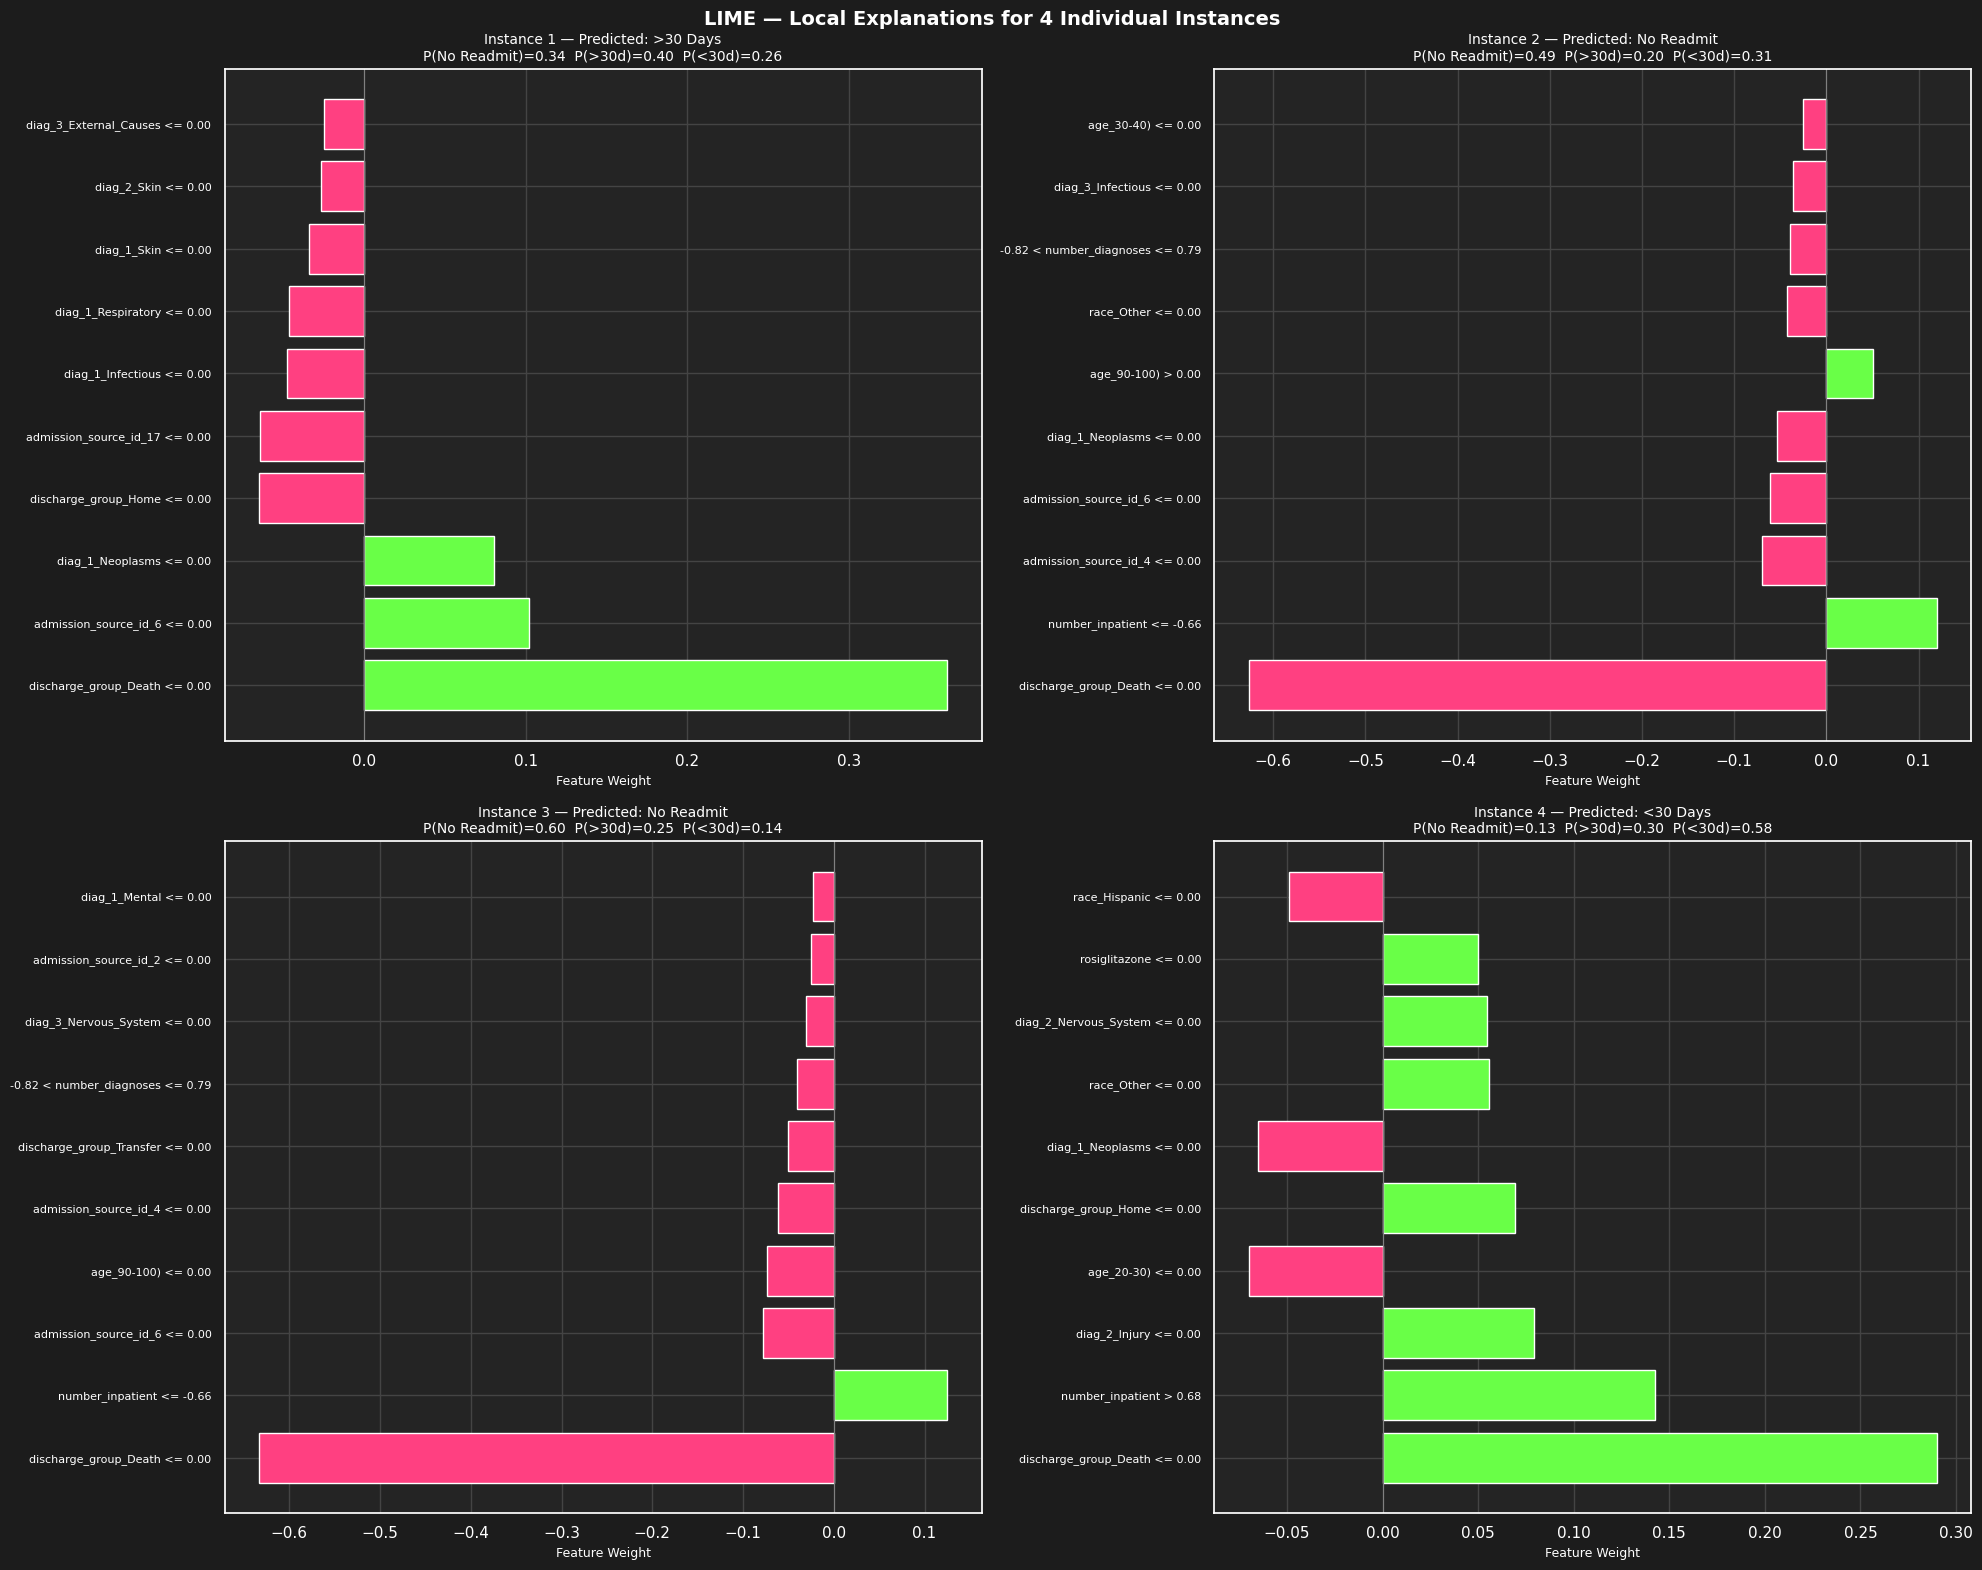

LIME saved ✓


In [46]:


lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = np.array(X_train_scaled),
    feature_names         = X_train_scaled.columns.tolist(),
    class_names           = CLASS_NAMES,
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

y_pred_lime = best_lgbm.predict(X_test_scaled)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('LIME — Local Explanations for 4 Individual Instances',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    instance = X_test_scaled.iloc[i].values
    pred_cls = int(y_pred_lime[i])

    exp = lime_explainer.explain_instance(
        instance,
        best_lgbm.predict_proba,
        num_features=10,
        num_samples=500,
        top_labels=1
    )

    label = list(exp.as_map().keys())[0]
    feat_weights = exp.as_list(label=label)
    features = [fw[0] for fw in feat_weights]
    weights  = [fw[1] for fw in feat_weights]
    colors   = ['#69ff47' if w > 0 else '#ff4081' for w in weights]

    ax.barh(range(len(features)), weights, color=colors)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.axvline(x=0, color='grey', lw=0.8)
    probas = best_lgbm.predict_proba([instance])[0]
    ax.set_title(
        f'Instance {i+1} — Predicted: {CLASS_NAMES[pred_cls]}\n'
        f'P(No Readmit)={probas[0]:.2f}  P(>30d)={probas[1]:.2f}  P(<30d)={probas[2]:.2f}',
        fontsize=10
    )
    ax.set_xlabel('Feature Weight', fontsize=9)

plt.tight_layout()
plt.savefig('lime_LGBM.png', dpi=120, bbox_inches='tight')
plt.show()
print('LIME saved ✓')


## XAI Technique 4 — Permutation Importance

Computing permutation importance on test set...


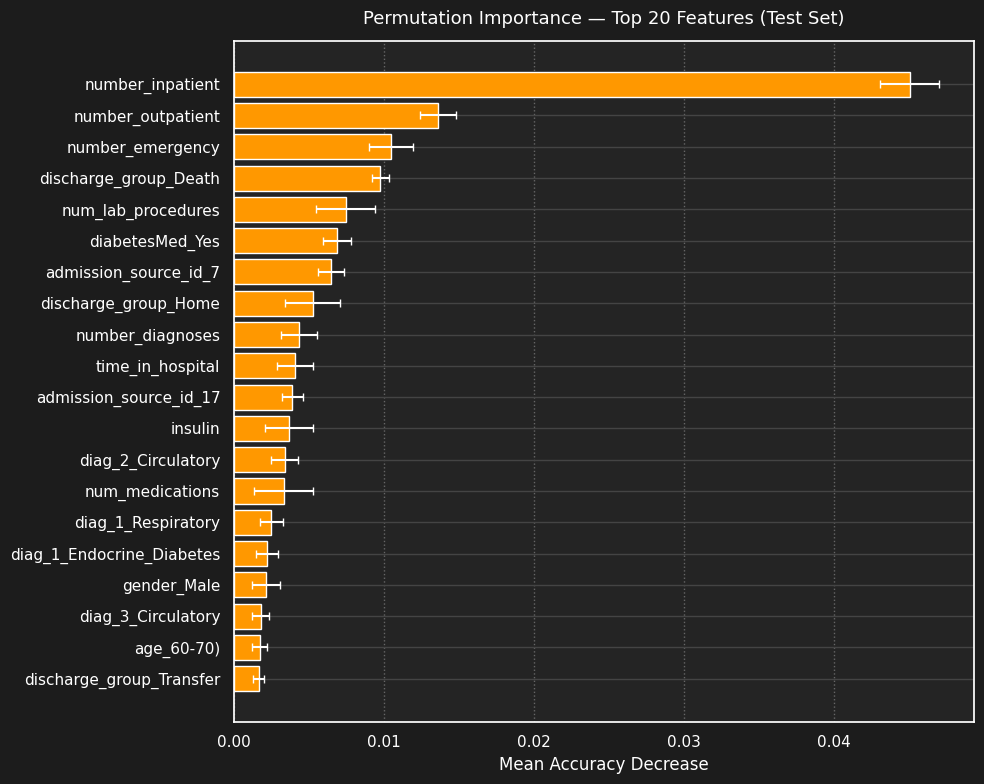


Top 10 features by permutation importance:
              feature  importance_mean  importance_std
     number_inpatient         0.045029        0.001942
    number_outpatient         0.013624        0.001187
     number_emergency         0.010496        0.001483
discharge_group_Death         0.009783        0.000560
   num_lab_procedures         0.007463        0.001962
      diabetesMed_Yes         0.006897        0.000917
admission_source_id_7         0.006479        0.000852
 discharge_group_Home         0.005272        0.001834
     number_diagnoses         0.004359        0.001180
     time_in_hospital         0.004094        0.001216
Permutation importance saved ✓


In [47]:


print('Computing permutation importance on test set...')

perm_result = permutation_importance(
    best_lgbm, X_test_scaled, y_test,
    n_repeats=10,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':         X_test_scaled.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#1c1c1c')
ax.set_facecolor('#242424')

ax.barh(
    perm_df['feature'][::-1],
    perm_df['importance_mean'][::-1],
    xerr=perm_df['importance_std'][::-1],
    color='#ff9800', ecolor='white', capsize=3
)
ax.set_title('Permutation Importance — Top 20 Features (Test Set)',
             color='white', fontsize=13, pad=12)
ax.set_xlabel('Mean Accuracy Decrease', color='white')
ax.tick_params(colors='white')
ax.grid(True, linestyle=':', alpha=0.3, color='white', axis='x')
plt.tight_layout()
plt.savefig('permutation_importance_LGBM.png', facecolor='#1c1c1c', dpi=120)
plt.show()

print('\nTop 10 features by permutation importance:')
print(perm_df[['feature','importance_mean','importance_std']].head(10).to_string(index=False))
print('Permutation importance saved ✓')
